In [2]:
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet(
  root="./data",
  split="test",
  download=True
)

In [3]:
# 이미지 타입 확인
image, label = dataset[0]

print(type(image)) # PIL Image 로 꺼내와줌
print(label) # 어떤 클래스인지 보여줌

<class 'PIL.Image.Image'>
0


In [4]:
len(dataset)

3669

In [5]:
from torch.utils.data import DataLoader
import torch

def collate_fn(batch):
  images, labels = zip(*batch)

  return list(images), torch.tensor(labels)

loader = DataLoader(
  dataset,
  batch_size=32,
  shuffle=True,
  collate_fn=collate_fn
)

In [6]:
# 이미지 뽑아주기
full_images = []
for images, _ in loader:
  full_images.extend(images)

In [7]:
from transformers import CLIPModel, AutoProcessor

MODEL_NAME = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_NAME)
processor = AutoProcessor.from_pretrained(MODEL_NAME)

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8450.27it/s]


In [8]:
len(full_images)

3669

In [ ]:
# BatchFeature 객체 계열
inputs = processor(
  images=full_images,
  return_tensors="pt"
)

print(type(inputs))
print(inputs.keys)
print(type(inputs["pixel_values"]))
print(inputs["pixel_values"].shape)

<class 'transformers.feature_extraction_utils.BatchFeature'>
<class 'torch.Tensor'>
torch.Size([3669, 3, 224, 224])


In [14]:
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(DEVICE)
model.eval()

# 
features_list = []

with torch.inference_mode():
  for images, _ in loader:

    # 여기에서는 CPU로 tensor 변환
    inputs = processor(
      images=images,
      return_tensors="pt"
    )

    # 모델에 입력하기 전에 tensor로 변환시켜주기
    pixel_values = inputs["pixel_values"].to(DEVICE)

    # image tensor -> vector
    outputs = model.get_image_features(
      pixel_values=pixel_values
    )

    # Tensor.Size[batch_size, vector_dims]
    features = outputs.pooler_output

    features = F.normalize(
      features,
      p=2,
      dim=-1
    )

    # 일반 메모리에 적재해주기 (list[Tensor.Size(batch, vector_dims)])
    features_list.append(features.cpu())

# 세로 방향으로 모두 합쳐주기
image_features = torch.cat(features_list, dim=0)


In [46]:
type(outputs)

transformers.modeling_outputs.BaseModelOutputWithPooling

In [21]:
type(image_features)

torch.Tensor

In [40]:
texts = [
  "a dog",
  "a cute cat"
]

texts_input = processor(
  text=texts,
  padding=True,
  return_tensors="pt"
)

type(texts_input), texts_input

(transformers.feature_extraction_utils.BatchFeature,
 {'input_ids': tensor([[49406,   320,  1929, 49407, 49407],
         [49406,   320,  2242,  2368, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 0],
         [1, 1, 1, 1, 1]])})

In [41]:
model.eval()

with torch.inference_mode():
  # 문자 토큰들을 벡터화해주기
  text_features = model.get_text_features(
    input_ids=texts_input["input_ids"].to(DEVICE),
    attention_mask=texts_input["attention_mask"].to(DEVICE)
  )

print(text_features.pooler_output.shape)

torch.Size([2, 512])


In [42]:
text_vec = text_features.pooler_output.cpu()
image_vec = image_features.cpu()

text_vec.shape, image_vec.shape

(torch.Size([2, 512]), torch.Size([3669, 512]))

In [43]:
# 결과는 [2, 3669]
similarities = text_vec @ image_vec.T 

# 각각의 행에서 가장 큰 클래스 번호를 뽑아주기
image_ids = similarities.argmax(dim=1).tolist()
image_ids

[3073, 3361]

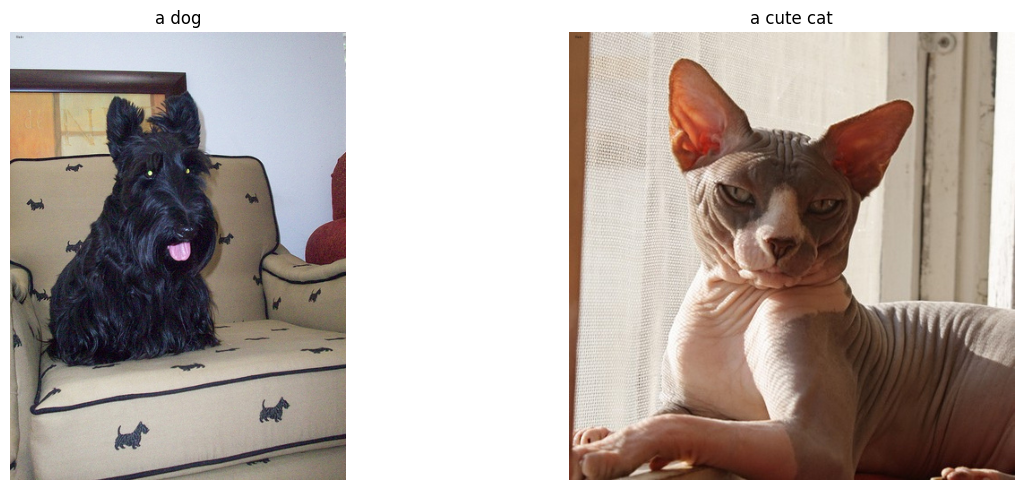

In [45]:
# 각각 문자열에 대한 이미지 출력해보기
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, image_id in zip(axes.flatten(), texts, image_ids):
  ax.set_title(text)
  ax.imshow(dataset[image_id][0])
  ax.axis("off")

fig.tight_layout()
plt.show()